In [52]:
import os, random
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score, median_absolute_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

SEED = 42
MIN_OBSERVED_TARGETS = 2
LOW_OBS_THRESHOLD = 30
IPS_MIN_PROBA = 0.05
IPS_MAX_WEIGHT = 20.0
ARCHETYPE_HIGH_SUPPORT = 20
ARCHETYPE_MEDIUM_SUPPORT = 8
ARCHETYPE_LOW_SUPPORT = 3

PERIOD_BUCKETS = ["pre_1945", "1945_1980", "1980_2000", "2000_2010", "post_2010"]
X_cols = [
    "Construction period",
    "Construction period bucket",
    "Typology",
    "Primary Code",
    "Hybrid Structure",
    "Country",
]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]


def to_period_bucket(year_series):
    year = pd.to_numeric(year_series, errors="coerce")
    return pd.cut(
        year,
        bins=[-np.inf, 1945, 1980, 2000, 2010, np.inf],
        labels=PERIOD_BUCKETS,
        right=False,
    )


def archetype_support_level(n_rows):
    if n_rows >= ARCHETYPE_HIGH_SUPPORT:
        return "high"
    if n_rows >= ARCHETYPE_MEDIUM_SUPPORT:
        return "medium"
    if n_rows >= ARCHETYPE_LOW_SUPPORT:
        return "low"
    if n_rows >= 1:
        return "very_low"
    return "none"


def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Imports complete.  SEED =", SEED)

# -- Visualisation style constants --
_C1   = "#4C72B0"   # main blue
_C2   = "#DD8452"   # accent orange
_REF  = "#C44E52"   # reference-line red
_GRAY = "#AAAAAA"

plt.rcParams.update({
    "figure.dpi":         110,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "font.size":          10,
})

Imports complete.  SEED = 42


In [53]:
# ==========================================================
# Data Preparation
# ==========================================================

def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df["Construction period bucket"] = to_period_bucket(df["Construction period"])
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64).copy()
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64).copy()
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64).copy()

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Construction period bucket", "Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_df=y_train_df,     y_val_df=y_val_df,      y_test_df=y_test_df,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        preprocessor=preprocessor,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )

In [54]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")

Data preparation complete.
X_train: (1799, 52)  y_train: (1799, 5)
X_val:   (385, 52)  y_val:   (385, 5)
X_test:  (386, 52)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)


In [55]:
# ==========================================================
# Archetype Support Threshold Diagnostics (training split)
# ==========================================================
# Archetype is defined by the full input tuple in X_cols.
# Use this output to set ARCHETYPE_HIGH/MEDIUM/LOW_SUPPORT in Cell 1.

archetype_counts = (
    data["X_train_raw"][X_cols]
    .astype("string")
    .fillna("<NA>")
    .value_counts()
)

print("Archetype support diagnostics (training split)")
print(f"Unique archetypes: {len(archetype_counts)}")
print(f"Total training rows: {len(data['X_train_raw'])}")
print()

desc = archetype_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95])
print("Distribution of rows per archetype:")
print(desc.to_string())
print()

# === SCHEME 1: Quantile-based ===
q = archetype_counts.quantile([0.25, 0.5, 0.75, 0.9]).round().astype(int)
suggest_low_q = max(1, int(q.loc[0.25]))
suggest_medium_q = max(suggest_low_q + 1, int(q.loc[0.5]))
suggest_high_q = max(suggest_medium_q + 1, int(q.loc[0.75]))

# === SCHEME 2: Practical floor (minimum practical coverage + buffer) ===
# Use min practical floor with some buffer for realistic confidence labeling
suggest_low_p = 3
suggest_medium_p = 8
suggest_high_p = 20

# Compute impact: what % of archetypes fall into each support level for both schemes
def compute_distribution(low, med, high, counts):
    """Count archetypes in each support level."""
    none_ct = (counts == 0).sum()
    low_ct = ((counts > 0) & (counts < low)).sum()
    med_ct = ((counts >= low) & (counts < med)).sum()
    high_ct = ((counts >= med) & (counts < high)).sum()
    vhigh_ct = (counts >= high).sum()
    return none_ct, low_ct, med_ct, high_ct, vhigh_ct

none_q, low_q, med_q, high_q, vhigh_q = compute_distribution(suggest_low_q, suggest_medium_q, suggest_high_q, archetype_counts)
none_p, low_p, med_p, high_p, vhigh_p = compute_distribution(suggest_low_p, suggest_medium_p, suggest_high_p, archetype_counts)

print("=" * 70)
print("SCHEME 1: Quantile-based (percentile-driven)")
print("=" * 70)
print(f"  LOW    = {suggest_low_q}  (25th percentile)")
print(f"  MEDIUM = {suggest_medium_q}  (50th percentile)")
print(f"  HIGH   = {suggest_high_q}  (75th percentile)")
print()
print("Archetype distribution:")
print(f"  None (0 rows):           {none_q:3d} archetypes")
print(f"  Low (1–{suggest_low_q-1}):            {low_q:3d} archetypes")
print(f"  Medium ({suggest_low_q}–{suggest_medium_q-1}):        {med_q:3d} archetypes")
print(f"  High ({suggest_medium_q}–{suggest_high_q-1}):         {high_q:3d} archetypes")
print(f"  V.High (≥{suggest_high_q}):       {vhigh_q:3d} archetypes")
print()

print("=" * 70)
print("SCHEME 2: Practical floor (minimum realistic coverage)")
print("=" * 70)
print(f"  LOW    = {suggest_low_p}  (min practical; ~25% of single-row archetypes)")
print(f"  MEDIUM = {suggest_medium_p}  (solid representation)")
print(f"  HIGH   = {suggest_high_p}  (strong archetype coverage)")
print()
print("Archetype distribution:")
print(f"  None (0 rows):           {none_p:3d} archetypes")
print(f"  Low (1–{suggest_low_p-1}):            {low_p:3d} archetypes")
print(f"  Medium ({suggest_low_p}–{suggest_medium_p-1}):       {med_p:3d} archetypes")
print(f"  High ({suggest_medium_p}–{suggest_high_p-1}):        {high_p:3d} archetypes")
print(f"  V.High (≥{suggest_high_p}):       {vhigh_p:3d} archetypes")
print()

print("=" * 70)
print("SUMMARY & RECOMMENDATION")
print("=" * 70)
print(f"Current thresholds: LOW={ARCHETYPE_LOW_SUPPORT}, MEDIUM={ARCHETYPE_MEDIUM_SUPPORT}, HIGH={ARCHETYPE_HIGH_SUPPORT}")
print()
print("Scheme 1 (Quantile) favors sensitivity: labels more archetypes as 'high'.")
print(f"Scheme 2 (Practical) is more conservative: requires {suggest_low_p}+ rows for 'low' confidence.")
print()
print(f"Top 10 archetypes: {archetype_counts.iloc[0]} rows (max) down to {archetype_counts.iloc[9]} rows (10th)")
print(f"Median archetype: {int(archetype_counts.median())} rows")

Archetype support diagnostics (training split)
Unique archetypes: 451
Total training rows: 1799

Distribution of rows per archetype:
count    451.000000
mean       3.988914
std        8.270556
min        1.000000
10%        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
90%        9.000000
95%       18.000000
max      101.000000

SCHEME 1: Quantile-based (percentile-driven)
  LOW    = 1  (25th percentile)
  MEDIUM = 2  (50th percentile)
  HIGH   = 3  (75th percentile)

Archetype distribution:
  None (0 rows):             0 archetypes
  Low (1–0):              0 archetypes
  Medium (1–1):        249 archetypes
  High (2–2):          73 archetypes
  V.High (≥3):       129 archetypes

SCHEME 2: Practical floor (minimum realistic coverage)
  LOW    = 3  (min practical; ~25% of single-row archetypes)
  MEDIUM = 8  (solid representation)
  HIGH   = 20  (strong archetype coverage)

Archetype distribution:
  None (0 rows):             0 archetypes
  Low (1–2):            

### Data Interpretation

Material intensity columns contain reported numeric values (typically positive) or missing values. Missing values are not interpreted as zero or as confirmed material absence. They reflect database incompleteness: a survey may not have recorded every material for every building.

This notebook estimates reported material intensity patterns from an incomplete database. The model supports database querying, gap exploration, and early-stage estimation, not verification of true physical material stocks.

**Stage 1** (`ObservationModel`)  predicts P(recorded | x): the probability that the database contains an intensity value for a given material in a building with features x.

**Stage 2** (`IntensityModel`)  estimates the intensity value (kg/m²), conditioned on the material being recorded, using quantile regression. Stage 1 recording probabilities are not appended as Stage 2 features; they are used only as inverse-propensity sample weights during Stage 2 training.

The main workflow uses raw observed material intensity values. Extreme values are retained because they are part of the reported database. Log transformation (log1p) is used to reduce skewness during model fitting.

In [56]:
# ==========================================================
# Missingness / Observation Rate Summary
# ==========================================================

header = (f"{'Material':<12}  {'n_train':>8}  {'obs%_train':>10}  "
          f"{'n_val':>6}  {'obs%_val':>8}  {'n_test':>7}  {'obs%_test':>9}")
print(header)
print("-" * len(header))

for m, mat in enumerate(y_cols):
    n_tr = int(data['y_train_mask'][:, m].sum())
    n_v  = int(data['y_val_mask'][:, m].sum())
    n_te = int(data['y_test_mask'][:, m].sum())
    r_tr = n_tr / len(data['y_train_mask']) * 100
    r_v  = n_v  / len(data['y_val_mask'])   * 100
    r_te = n_te / len(data['y_test_mask'])  * 100
    print(f"{mat:<12}  {n_tr:>8}  {r_tr:>9.1f}%  "
          f"{n_v:>6}  {r_v:>7.1f}%  {n_te:>7}  {r_te:>8.1f}%")


Material       n_train  obs%_train   n_val  obs%_val   n_test  obs%_test
------------------------------------------------------------------------
Concrete          1385       77.0%     282     73.2%      297      76.9%
Glass              886       49.2%     176     45.7%      193      50.0%
Steel             1638       91.1%     344     89.4%      346      89.6%
Wood              1452       80.7%     316     82.1%      313      81.1%
Brick             1200       66.7%     257     66.8%      277      71.8%


In [57]:
# ==========================================================
# Data Quality: Extreme Value Diagnostic
# ==========================================================
# Extreme values are RETAINED in the main model.
# This table flags records above the 99th percentile
# for awareness only. No values are removed or altered.

print("Extreme value diagnostic — all rows combined (train + val + test)")
print("Extreme values are retained in training, evaluation, and visualisations.")
print()
print(f"{'Material':<12}  {'n_obs':>6}  {'p99 (kg/m2)':>12}  {'max (kg/m2)':>12}  {'n_above_p99':>12}  {'pct_above':>10}")
print("-" * 72)

y_all_raw  = np.vstack([data["y_train_raw"],  data["y_val_raw"],  data["y_test_raw"]])
y_all_mask = np.vstack([data["y_train_mask"], data["y_val_mask"], data["y_test_mask"]])

for m, mat in enumerate(y_cols):
    obs = y_all_mask[:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  insufficient data")
        continue
    vals    = y_all_raw[obs, m]
    p99     = np.percentile(vals, 99)
    vmax    = vals.max()
    n_above = int((vals > p99).sum())
    pct     = n_above / len(vals) * 100
    flag    = "  <-- review" if vmax > p99 * 5 else ""
    print(f"{mat:<12}  {int(obs.sum()):>6}  {p99:>12.1f}  {vmax:>12.1f}  "
          f"{n_above:>12}  {pct:>9.1f}%{flag}")

Extreme value diagnostic — all rows combined (train + val + test)
Extreme values are retained in training, evaluation, and visualisations.

Material       n_obs   p99 (kg/m2)   max (kg/m2)   n_above_p99   pct_above
------------------------------------------------------------------------
Concrete        1964        4683.4        9876.5            20        1.0%
Glass           1255          14.0          30.8            13        1.0%
Steel           2328         425.1        2059.2            24        1.0%
Wood            2081         163.0         869.0            21        1.0%  <-- review
Brick           1734        2148.3       32969.7            18        1.0%  <-- review


In [58]:
# ==========================================================
# Stage 1 — Observation Model
# ==========================================================
#
# Predicts P(recorded | x) per material.
# Target: material_column.notna()   (NOT material presence/absence)
# Missing != absent; missing = database gap.
#
# One CalibratedClassifierCV(XGBClassifier, method='sigmoid') per material.

class ObservationModel:
    """Per-material XGBoost classifier predicting P(recorded | x)."""

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            objective="binary:logistic", verbosity=0,
        )
        self.models_ = {}
        self.trivial_proba_ = {}

    def fit(self, X, y_observed):
        """Fit one CalibratedClassifierCV per material.

        Parameters
        ----------
        X          : (n, d) preprocessed feature matrix
        y_observed : (n, M) bool  --  True where intensity was recorded
        """
        self.models_ = {}
        self.trivial_proba_ = {}
        for m, material in enumerate(y_cols):
            s = y_observed[:, m].astype(int)
            p = float(s.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
            else:
                base = XGBClassifier(**self.xgb_params)
                clf  = CalibratedClassifierCV(base, method="sigmoid", cv=5)
                clf.fit(X, s)
                self.models_[material] = clf
        return self

    def predict_proba(self, X):
        """Return (n, M) array of P(recorded | x) for each material."""
        n = X.shape[0]
        proba = np.zeros((n, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            clf = self.models_.get(material)
            if clf is None:
                proba[:, m] = self.trivial_proba_.get(material, 0.0)
            else:
                proba[:, m] = clf.predict_proba(X)[:, 1]
        return proba


In [59]:
# ==========================================================
# Stage 2 — Intensity Model
# ==========================================================
#
# Per-material dual-head XGBoost trained on observed rows only.
# Log1p transformation: target = log1p(y) = log(1 + y).  No clipping applied.
#
# Head 1: Quantile regression with alpha = [0.05, 0.50, 0.95]
# Head 2: Mean prediction (standard L2 regression)
#
# Stage 1 probabilities are NOT appended as Stage 2 features.
# They are used only as inverse-propensity sample weights during Stage 2 fitting.
#
# per_material_params: optional dict {material_name: {param: value, ...}}
#   overrides the global xgb_params for that material only.

class IntensityModel:
    """Per-material dual-head XGBoost estimating conditional intensity (kg/m^2)."""

    ALPHAS = [0.05, 0.50, 0.95]

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED,
                 per_material_params=None):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            verbosity=0,
        )
        self.per_material_params = per_material_params or {}
        self.models_ = {}
        self.mean_models_ = {}

    @staticmethod
    def _inverse_propensity_weights(p_recorded_obs):
        p = np.clip(np.asarray(p_recorded_obs, dtype=np.float64), IPS_MIN_PROBA, 1.0)
        w = 1.0 / p
        w = np.minimum(w, IPS_MAX_WEIGHT)
        # Keep mean weight near 1.0 for stable optimization across materials.
        return w / np.mean(w)

    def fit(self, X, y_raw, y_observed, p_recorded=None):
        """Train quantile and mean XGBoost per material on observed rows.

        Parameters
        ----------
        X          : (n, d) preprocessed feature matrix
        y_raw      : (n, M) float  --  intensity values (NaN where unobserved)
        y_observed : (n, M) bool   --  True where intensity was recorded
        p_recorded : (n, M) float  --  Stage 1 P(recorded|x), used only for IPS weighting
        """
        self.models_ = {}
        self.mean_models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_observed[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                self.mean_models_[material] = None
                continue
            y_log = np.log1p(y_raw[obs, m])
            if p_recorded is None:
                sw = np.ones(obs.sum(), dtype=np.float64)
            else:
                sw = self._inverse_propensity_weights(p_recorded[obs, m])

            # Merge global params with any per-material overrides
            mat_params = {**self.xgb_params, **self.per_material_params.get(material, {})}

            # Head 1: Quantile regression
            mdl = XGBRegressor(
                objective="reg:quantileerror",
                quantile_alpha=self.ALPHAS,
                **mat_params,
            )
            mdl.fit(X[obs], y_log, sample_weight=sw)
            self.models_[material] = mdl

            # Head 2: Mean prediction (L2)
            mean_mdl = XGBRegressor(
                objective="reg:squarederror",
                **mat_params,
            )
            mean_mdl.fit(X[obs], y_log, sample_weight=sw)
            self.mean_models_[material] = mean_mdl
        return self

    def predict_quantiles(self, X):
        """Return p05/p50/p95 in original (kg/m^2) space per material.

        Intervals are the direct expm1-transformed outputs of the quantile
        regression model (quantile_alpha = [0.05, 0.50, 0.95]).
        Inverse of log1p is expm1; no clipping or Gaussian approximation is used.

        Returns dict: material -> {"p05": array, "p50": array, "p95": array}
        """
        n = X.shape[0]
        result = {}
        for material in y_cols:
            mdl = self.models_.get(material)
            if mdl is None:
                result[material] = {"p05": np.zeros(n), "p50": np.zeros(n), "p95": np.zeros(n)}
                continue
            pq   = mdl.predict(X)      # (n, 3): [log1p_p05, log1p_p50, log1p_p95]
            p_lo = np.maximum(np.expm1(pq[:, 0]), 0.0)
            p50  = np.maximum(np.expm1(pq[:, 1]), 0.0)
            p_hi = np.maximum(np.expm1(pq[:, 2]), 0.0)
            result[material] = {"p05": p_lo, "p50": p50, "p95": p_hi}
        return result

    def predict_means(self, X):
        """Return mean prediction in original (kg/m^2) space per material.

        Returns dict: material -> array of mean predictions
        """
        n = X.shape[0]
        result = {}
        for material in y_cols:
            mdl = self.mean_models_.get(material)
            if mdl is None:
                result[material] = np.zeros(n)
                continue
            y_mean_log = mdl.predict(X)
            y_mean = np.maximum(np.expm1(y_mean_log), 0.0)
            result[material] = y_mean
        return result

In [60]:
# ==========================================================
# FinalQueryModel — two-stage wrapper
# ==========================================================

class FinalQueryModel:
    """Two-stage database-informed query model.

    Stage 1 (tuned_observation_model): P(recorded | x) per material.
    Stage 2 (tuned_intensity_model):   conditional intensity quantiles + mean (kg/m^2).
      Quantiles at [0.05, 0.50, 0.95] via quantile regression.
      Mean via standard L2 regression.
      Per-material hyperparameters via per_material_intensity_params.

    Archetype-mean blending: for buildings whose archetype (full X_cols tuple)
    appears in training data, p50 and mean predictions are blended toward the
    empirical archetype mean.  Blend weight grows linearly from 0 (no support)
    to BLEND_MAX_ALPHA at ARCHETYPE_HIGH_SUPPORT rows, then stays capped.
    p05/p95 interval bounds are not shifted.

    query() output per material
    ---------------------------
    database_reporting_probability   float   P(recorded | x)
    p_recorded                       float   alias of database_reporting_probability
    p05, p50, p95                    float   conditional intensity quantiles (kg/m^2)
    mean                             float   conditional intensity mean (kg/m^2)
    expected_reported                float   p_recorded * p50
    n_observed_train                 int     training rows with this material recorded
    coverage_warning                 bool    True if n_observed_train < LOW_OBS_THRESHOLD
    archetype_n_train                int     training rows matching the full input archetype
    archetype_support_level          str     qualitative support label from archetype_n_train
    """

    BLEND_MAX_ALPHA = 0.0  # blending disabled; set > 0 to re-enable archetype-mean blending

    def __init__(self, observation_params=None, intensity_params=None,
                 per_material_intensity_params=None):
        _default = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=0.0, reg_lambda=1.0, random_state=SEED)
        self.tuned_observation_model = ObservationModel(**(observation_params or _default))
        self.tuned_intensity_model   = IntensityModel(
            **(intensity_params or _default),
            per_material_params=per_material_intensity_params,
        )

    @staticmethod
    def _archetype_key_row(row):
        return tuple("<NA>" if pd.isna(v) else str(v) for v in row)

    def _build_archetype_count_map(self, X_raw):
        if X_raw is None:
            return {}
        xdf = pd.DataFrame(X_raw).copy()
        xdf = xdf[X_cols].copy()
        keys = xdf.apply(self._archetype_key_row, axis=1)
        counts = keys.value_counts()
        return {k: int(v) for k, v in counts.items()}

    def _build_archetype_means(self, X_raw, y_raw, y_mask):
        """Per-archetype, per-material mean intensity (original scale) from training."""
        xdf = X_raw[X_cols].copy().reset_index(drop=True)
        keys = xdf.apply(self._archetype_key_row, axis=1)
        # Group by archetype key with a plain dict to avoid numpy
        # broadcasting errors when comparing arrays of tuples.
        key_to_rows = {}
        for i, k in enumerate(keys):
            key_to_rows.setdefault(k, []).append(i)
        archetype_means = {}
        for key, row_indices in key_to_rows.items():
            row_idx = np.array(row_indices)
            archetype_means[key] = {}
            for m in range(len(y_cols)):
                obs = y_mask[row_idx, m]
                if obs.sum() >= 1:
                    archetype_means[key][m] = float(np.mean(y_raw[row_idx[obs], m]))
                else:
                    archetype_means[key][m] = np.nan
        return archetype_means

    def fit(self, X_proc, y_raw, y_mask, X_raw=None):
        y_observed = y_mask
        self.n_observed_train_ = {
            mat: int(y_observed[:, m].sum()) for m, mat in enumerate(y_cols)
        }
        self.archetype_count_map_ = self._build_archetype_count_map(X_raw)
        self.archetype_means_ = (
            self._build_archetype_means(X_raw, y_raw, y_mask)
            if X_raw is not None else {}
        )
        self.tuned_observation_model.fit(X_proc, y_observed)
        p_recorded = self.tuned_observation_model.predict_proba(X_proc)
        self.tuned_intensity_model.fit(X_proc, y_raw, y_observed, p_recorded=p_recorded)
        return self

    def query(self, X_proc, X_raw=None):
        """Query the model for one or more buildings.

        Parameters
        ----------
        X_proc : (n, d) preprocessed feature matrix
        X_raw  : (n, len(X_cols)) raw feature rows for archetype support matching

        Returns
        -------
        dict: material -> {database_reporting_probability, p_recorded, p05, p50, p95, mean,
                           expected_reported, n_observed_train, coverage_warning,
                           archetype_n_train, archetype_support_level}
        """
        p_recorded = self.tuned_observation_model.predict_proba(X_proc)
        intervals  = self.tuned_intensity_model.predict_quantiles(X_proc)
        means_dict = self.tuned_intensity_model.predict_means(X_proc)

        n = X_proc.shape[0]
        if X_raw is None or not getattr(self, "archetype_count_map_", None):
            archetype_n   = np.full(n, np.nan)
            archetype_lvl = np.array(["unknown"] * n, dtype=object)
        else:
            xdf = pd.DataFrame(X_raw).copy()
            xdf = xdf[X_cols].copy()
            keys = xdf.apply(self._archetype_key_row, axis=1)
            archetype_n = np.array(
                [self.archetype_count_map_.get(k, 0) for k in keys],
                dtype=np.int64,
            )
            archetype_lvl = np.array(
                [archetype_support_level(int(v)) for v in archetype_n], dtype=object
            )

            # Blend p50 and mean toward archetype training mean, weighted by support.
            # Blending starts only at ARCHETYPE_MEDIUM_SUPPORT (8 rows) and grows
            # linearly to BLEND_MAX_ALPHA at ARCHETYPE_HIGH_SUPPORT (20 rows).
            # p05/p95 interval bounds are not shifted.
            _eff_n  = np.maximum(archetype_n - ARCHETYPE_MEDIUM_SUPPORT, 0)
            _scale  = ARCHETYPE_HIGH_SUPPORT - ARCHETYPE_MEDIUM_SUPPORT  # 20 - 8 = 12
            blend_w = np.clip(_eff_n / _scale, 0.0, 1.0) * self.BLEND_MAX_ALPHA
            arch_keys = keys.values

            for m, mat in enumerate(y_cols):
                arch_means_arr = np.array(
                    [self.archetype_means_.get(k, {}).get(m, np.nan) for k in arch_keys],
                    dtype=np.float64,
                )
                valid = np.isfinite(arch_means_arr) & (blend_w > 0)
                if valid.any():
                    w = blend_w[valid]
                    intervals[mat]["p50"][valid] = (
                        (1.0 - w) * intervals[mat]["p50"][valid]
                        + w * arch_means_arr[valid]
                    )
                    means_dict[mat][valid] = (
                        (1.0 - w) * means_dict[mat][valid]
                        + w * arch_means_arr[valid]
                    )

        result = {}
        for m, mat in enumerate(y_cols):
            n_obs = self.n_observed_train_.get(mat, 0)
            result[mat] = {
                "database_reporting_probability": p_recorded[:, m],
                "p_recorded":                      p_recorded[:, m],
                "p05":                             intervals[mat]["p05"],
                "p50":                             intervals[mat]["p50"],
                "p95":                             intervals[mat]["p95"],
                "mean":                            means_dict[mat],
                "expected_reported":               p_recorded[:, m] * intervals[mat]["p50"],
                "n_observed_train":                n_obs,
                "coverage_warning":                n_obs < LOW_OBS_THRESHOLD,
                "archetype_n_train":               archetype_n,
                "archetype_support_level":         archetype_lvl,
            }
        return result

In [61]:
# ==========================================================
# Hyperparameter Tuning (Optuna)
# Uses training set to fit, validation set to evaluate.
# Test set is untouched until final evaluation.
# ==========================================================

N_TRIALS = 40          # trials for Stage 1 and global Stage 2
N_TRIALS_PER_MAT = 40  # trials per material for per-material Stage 2

# ── Stage 1: Observation Model ────────────────────────────────────────────────
def _obs_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
        max_depth        = trial.suggest_int(  "max_depth",          3,   6),
        learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample",        0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
        random_state     = SEED,
    )
    m = ObservationModel(**params)
    m.fit(data["X_train_proc"], data["y_train_mask"])
    p = m.predict_proba(data["X_val_proc"])
    aucs = [
        roc_auc_score(data["y_val_mask"][:, i].astype(int), p[:, i])
        for i in range(len(y_cols))
        if 0 < data["y_val_mask"][:, i].sum() < len(data["y_val_mask"])
    ]
    return -np.mean(aucs) if aucs else 0.0

obs_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
obs_study.optimize(_obs_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_observation_params = {**obs_study.best_params, "random_state": SEED}
print(f"Stage 1 best  mean AUC = {-obs_study.best_value:.4f}")
print("best_observation_params:", best_observation_params)

# Precompute Stage 1 recording probabilities on train for Stage 2 IPS weighting.
obs_for_ips = ObservationModel(**best_observation_params)
obs_for_ips.fit(data["X_train_proc"], data["y_train_mask"])
p_rec_train_for_ips = obs_for_ips.predict_proba(data["X_train_proc"])

# ── Stage 2: Global Intensity Model (shared hyperparams, used as fallback) ───
def _int_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
        max_depth        = trial.suggest_int(  "max_depth",          3,   6),
        learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample",        0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
        random_state     = SEED,
    )
    m = IntensityModel(**params)
    m.fit(
        data["X_train_proc"],
        data["y_train_raw"],
        data["y_train_mask"],
        p_recorded=p_rec_train_for_ips,
    )
    ivs = m.predict_quantiles(data["X_val_proc"])
    maes = [
        mean_absolute_error(data["y_val_raw"][data["y_val_mask"][:, i], i],
                            ivs[mat]["p50"][data["y_val_mask"][:, i]])
        for i, mat in enumerate(y_cols)
        if data["y_val_mask"][:, i].sum() >= 2
    ]
    return np.mean(maes) if maes else 0.0

int_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
int_study.optimize(_int_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_intensity_params = {**int_study.best_params, "random_state": SEED}
print(f"\nStage 2 global best  mean MAE = {int_study.best_value:.4f}")
print("best_intensity_params:", best_intensity_params)

# ── Stage 2: Per-material Intensity Model (individual hyperparams per material)
# Each study trains only the quantile head for one material — fast single XGBoost per trial.
print("\nPer-material Stage 2 tuning (one study per material)...")
best_intensity_params_per_material = {}

for mat_idx, mat in enumerate(y_cols):
    obs_tr  = data["y_train_mask"][:, mat_idx]
    obs_val = data["y_val_mask"][:, mat_idx]

    if obs_tr.sum() < 2 or obs_val.sum() < 2:
        best_intensity_params_per_material[mat] = {}
        continue

    def _int_obj_mat(trial, _m=mat_idx, _obs_tr=obs_tr, _obs_val=obs_val):
        params = dict(
            n_estimators     = trial.suggest_int(  "n_estimators",     100, 500),
            max_depth        = trial.suggest_int(  "max_depth",          3,   6),
            learning_rate    = trial.suggest_float("learning_rate",   0.01, 0.2, log=True),
            subsample        = trial.suggest_float("subsample",        0.6, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 2.0),
            reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 5.0),
            random_state     = SEED, verbosity=0,
        )
        y_log = np.log1p(data["y_train_raw"][_obs_tr, _m])
        sw    = IntensityModel._inverse_propensity_weights(p_rec_train_for_ips[_obs_tr, _m])
        mdl   = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=IntensityModel.ALPHAS,
            **params,
        )
        mdl.fit(data["X_train_proc"][_obs_tr], y_log, sample_weight=sw)
        p50_log = mdl.predict(data["X_val_proc"])[:, 1]
        y_pred  = np.maximum(np.expm1(p50_log), 0.0)
        return mean_absolute_error(data["y_val_raw"][_obs_val, _m], y_pred[_obs_val])

    mat_study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
    mat_study.optimize(_int_obj_mat, n_trials=N_TRIALS_PER_MAT, show_progress_bar=True)
    best_intensity_params_per_material[mat] = {**mat_study.best_params, "random_state": SEED}
    print(f"  {mat:<10}  best val MAE = {mat_study.best_value:.4f}  "
          f"(n_est={best_intensity_params_per_material[mat]['n_estimators']}, "
          f"depth={best_intensity_params_per_material[mat]['max_depth']})")

print("\nbest_intensity_params_per_material:")
for mat, p in best_intensity_params_per_material.items():
    print(f"  {mat}: {p}")

Best trial: 33. Best value: -0.957: 100%|██████████| 40/40 [01:36<00:00,  2.41s/it]   


Stage 1 best  mean AUC = 0.9570
best_observation_params: {'n_estimators': 217, 'max_depth': 6, 'learning_rate': 0.16176594158467525, 'subsample': 0.9993047660551292, 'colsample_bytree': 0.6641876259134049, 'reg_alpha': 0.7644481248030368, 'reg_lambda': 1.2733633413148846, 'random_state': 42}


Best trial: 11. Best value: 138.161: 100%|██████████| 40/40 [01:06<00:00,  1.66s/it]



Stage 2 global best  mean MAE = 138.1607
best_intensity_params: {'n_estimators': 242, 'max_depth': 5, 'learning_rate': 0.04842973130729267, 'subsample': 0.7114516496119322, 'colsample_bytree': 0.8788623593360378, 'reg_alpha': 0.04940924881227371, 'reg_lambda': 1.6040211894433964, 'random_state': 42}

Per-material Stage 2 tuning (one study per material)...


Best trial: 38. Best value: 417.019: 100%|██████████| 40/40 [00:13<00:00,  2.89it/s]


...

  Steel       best val MAE = 25.8469  (n_est=250, depth=6)


Best trial: 37. Best value: 11.5402: 100%|██████████| 40/40 [00:10<00:00,  3.80it/s]


  Wood        best val MAE = 11.5402  (n_est=432, depth=4)


Best trial: 13. Best value: 228.724: 100%|██████████| 40/40 [00:10<00:00,  3.76it/s]

  Brick       best val MAE = 228.7236  (n_est=404, depth=4)

best_intensity_params_per_material:
  Concrete: {'n_estimators': 403, 'max_depth': 6, 'learning_rate': 0.01581542903944683, 'subsample': 0.7603462978067851, 'colsample_bytree': 0.781895642725427, 'reg_alpha': 0.37504340778618583, 'reg_lambda': 0.7845723792609753, 'random_state': 42}
  Glass: {'n_estimators': 174, 'max_depth': 6, 'learning_rate': 0.10196967939171485, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595, 'reg_alpha': 1.1957999576221703, 'reg_lambda': 4.6484340576040255, 'random_state': 42}
  Steel: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.3119890406724053, 'reg_lambda': 0.7613762547568976, 'random_state': 42}
  Wood: {'n_estimators': 432, 'max_depth': 4, 'learning_rate': 0.02568585551795969, 'subsample': 0.9892211831491465, 'colsample_bytree': 0.9606759164739413, 'reg_alp

In [62]:
# ==========================================================
# Train Final Model with Tuned Hyperparameters
# ==========================================================

set_global_seed(SEED)
final_query_model = FinalQueryModel(
    observation_params=best_observation_params,
    intensity_params=best_intensity_params,
    per_material_intensity_params=best_intensity_params_per_material,
)
final_query_model.fit(
    data["X_train_proc"],
    data["y_train_raw"],
    data["y_train_mask"],
    X_raw=data["X_train_raw"],
)

# Expose components for evaluation
tuned_observation_model = final_query_model.tuned_observation_model
tuned_intensity_model   = final_query_model.tuned_intensity_model

print("Final model trained.")
for mat, n in final_query_model.n_observed_train_.items():
    warn = "  *** low-data warning" if n < LOW_OBS_THRESHOLD else ""
    print(f"  {mat:<10}  {n:>4} training observations{warn}")

print(f"\nArchetype means stored for {len(final_query_model.archetype_means_)} archetypes.")
print(f"BLEND_MAX_ALPHA = {FinalQueryModel.BLEND_MAX_ALPHA}  "
      f"(applied when archetype_n >= {ARCHETYPE_HIGH_SUPPORT})")

Final model trained.
  Concrete    1385 training observations
  Glass        886 training observations
  Steel       1638 training observations
  Wood        1452 training observations
  Brick       1200 training observations

Archetype means stored for 451 archetypes.
BLEND_MAX_ALPHA = 0.0  (applied when archetype_n >= 20)


In [63]:
# ==========================================================
# Stage 1 Evaluation — Recording Probability Model
# Metrics: AUC-ROC, Accuracy, Precision, Recall, F1 (threshold 0.5)
# Evaluated on the held-out test set.
# ==========================================================

p_rec_test = tuned_observation_model.predict_proba(data["X_test_proc"])
y_test_obs  = data["y_test_mask"]

rows = []
for m, mat in enumerate(y_cols):
    y_true = y_test_obs[:, m].astype(int)
    y_prob = p_rec_test[:, m]
    y_pred = (y_prob > 0.5).astype(int)
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        rows.append({"Material": mat, "AUC": "—", "Accuracy": "—",
                     "Precision": "—", "Recall": "—", "F1": "—",
                     "n_pos": int(y_true.sum()), "n_neg": int((1 - y_true).sum())})
        continue
    rows.append({
        "Material":  mat,
        "AUC":       round(roc_auc_score(y_true, y_prob), 3),
        "Accuracy":  round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_true, y_pred), 3),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0), 3),
        "n_pos":     int(y_true.sum()),
        "n_neg":     int((1 - y_true).sum()),
    })

print("Stage 1 — Recording probability model  (test set)")
print(pd.DataFrame(rows).to_string(index=False))


Stage 1 — Recording probability model  (test set)
Material   AUC  Accuracy  Precision  Recall    F1  n_pos  n_neg
Concrete 0.971     0.925      0.944   0.960 0.952    297     89
   Glass 0.966     0.912      0.944   0.876 0.909    193    193
   Steel 0.980     0.961      0.972   0.986 0.978    346     40
    Wood 0.952     0.927      0.952   0.958 0.955    313     73
   Brick 0.944     0.899      0.941   0.917 0.929    277    109


In [64]:
# ==========================================================
# Stage 2 Evaluation — Conditional Intensity: Point Estimates
# Metrics: MAE, RMSE, R2, Median AE  (observed rows only)
# Evaluated on the held-out test set.
# ==========================================================

intervals_test = tuned_intensity_model.predict_quantiles(data["X_test_proc"])

print("Stage 2 — Conditional intensity model  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'MAE':>8}  {'RMSE':>8}  {'R2':>8}  {'MedianAE':>9}")
print("-" * 60)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  {'—':>6}")
        continue
    y_true = data["y_test_raw"][obs, m]
    y_hat  = intervals_test[mat]["p50"][obs]
    mae    = mean_absolute_error(y_true, y_hat)
    rmse   = np.sqrt(mean_squared_error(y_true, y_hat))
    r2     = r2_score(y_true, y_hat)
    medae  = median_absolute_error(y_true, y_hat)
    print(f"{mat:<12}  {int(obs.sum()):>6}  {mae:>8.2f}  {rmse:>8.2f}  {r2:>8.3f}  {medae:>9.2f}")


Stage 2 — Conditional intensity model  (test set, observed rows only)
Material       n_obs       MAE      RMSE        R2   MedianAE
------------------------------------------------------------
Concrete         297    496.27    957.98     0.151     298.32
Glass            193      1.17      1.82     0.378       0.74
Steel            346     19.79     55.99     0.202       7.58
Wood             313      9.62     20.60     0.543       3.99
Brick            277    237.81    655.25     0.141     134.02


In [65]:
# ==========================================================
# Stage 2 Improvement Summary
# Compares three models on the held-out test set (observed rows only):
#   (A) Original: global Optuna params, no blending  [prior run baseline]
#   (B) Per-material: per-material Optuna params, no blending
#   (C) Final: per-material params + archetype-mean blending
#
# (B) comes from tuned_intensity_model.predict_quantiles() — per-material params
# (C) comes from final_query_model.query() — per-material params + blending
# ==========================================================

_query_test = final_query_model.query(data["X_test_proc"], X_raw=data["X_test_raw"])

print("Stage 2 improvement summary  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'MAE (B) no-blend':>18}  {'MAE (C) blended':>17}  {'Delta MAE':>10}  {'R2 (B)':>8}  {'R2 (C)':>8}")
print("-" * 90)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        continue
    y_true = data["y_test_raw"][obs, m]

    # (B) per-material tuned, no blending
    y_b = intervals_test[mat]["p50"][obs]
    mae_b = mean_absolute_error(y_true, y_b)
    r2_b  = r2_score(y_true, y_b)

    # (C) per-material tuned + archetype-mean blended
    y_c = _query_test[mat]["p50"][obs]
    mae_c = mean_absolute_error(y_true, y_c)
    r2_c  = r2_score(y_true, y_c)

    delta = mae_c - mae_b
    flag  = " <better" if delta < 0 else (" <worse" if delta > 0 else "")
    print(f"{mat:<12}  {int(obs.sum()):>6}  {mae_b:>18.2f}  {mae_c:>17.2f}  {delta:>+10.2f}{flag}  {r2_b:>8.3f}  {r2_c:>8.3f}")

# Proportion of test rows that received blending
n_blended = (
    np.array([_query_test[y_cols[0]]["archetype_support_level"]])
    != "very_low"
).sum()
print(f"\nRows with blend weight > 0: "
      f"{int((np.array([_query_test[y_cols[0]]['archetype_n_train']]) > 0).sum())} / {len(data['X_test_proc'])}")

Stage 2 improvement summary  (test set, observed rows only)
Material       n_obs    MAE (B) no-blend    MAE (C) blended   Delta MAE    R2 (B)    R2 (C)
------------------------------------------------------------------------------------------
Concrete         297              496.27             496.27       +0.00     0.151     0.151
Glass            193                1.17               1.17       +0.00     0.378     0.378
Steel            346               19.79              19.79       +0.00     0.202     0.202
Wood             313                9.62               9.62       +0.00     0.543     0.543
Brick            277              237.81             237.81       +0.00     0.141     0.141

Rows with blend weight > 0: 320 / 386


In [66]:
# ==========================================================
# Stage 2 Evaluation — Prediction Interval Coverage and Width
# Nominal 90% interval (alpha = 0.10)
# Validation-set conformal calibration used only to estimate offsets.
# ==========================================================

CAL_ALPHA = 0.10

def _conformal_offset(y_true, p05, p95, alpha=CAL_ALPHA):
    scores = np.maximum(p05 - y_true, y_true - p95)
    scores = np.asarray(scores, dtype=np.float64)
    scores = scores[np.isfinite(scores)]
    if scores.size == 0:
        return 0.0
    k = int(np.ceil((scores.size + 1) * (1.0 - alpha)))
    k = max(1, min(k, scores.size))
    return float(np.sort(scores)[k - 1])

intervals_val = tuned_intensity_model.predict_quantiles(data["X_val_proc"])
validation_offsets = {}
for m, mat in enumerate(y_cols):
    obs = data["y_val_mask"][:, m]
    if obs.sum() < 2:
        validation_offsets[mat] = 0.0
        continue
    y_true = data["y_val_raw"][obs, m]
    p05    = intervals_val[mat]["p05"][obs]
    p95    = intervals_val[mat]["p95"][obs]
    validation_offsets[mat] = _conformal_offset(y_true, p05, p95)

intervals_test_calibrated = {
    mat: {
        "p05": intervals_test[mat]["p05"] - validation_offsets[mat],
        "p50": intervals_test[mat]["p50"],
        "p95": intervals_test[mat]["p95"] + validation_offsets[mat],
    }
    for mat in y_cols
}

print("Validation-set conformal offsets (estimated on validation only)")
print(f"{'Material':<12}  {'n_val':>6}  {'Offset':>10}")
print("-" * 32)
for m, mat in enumerate(y_cols):
    n_val_obs = int(data["y_val_mask"][:, m].sum())
    print(f"{mat:<12}  {n_val_obs:>6}  {validation_offsets[mat]:>10.2f}")

print()
print("Stage 2 — 90% prediction interval  (test set, observed rows only)")
print(f"{'Material':<12}  {'n_obs':>6}  {'UncalCov':>9}  {'CalCov':>9}  {'UncalMeanW':>12}  {'CalMeanW':>10}  {'UncalMedW':>12}  {'CalMedW':>10}")
print("-" * 96)

for m, mat in enumerate(y_cols):
    obs = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        print(f"{mat:<12}  {'—':>6}")
        continue
    y_true = data["y_test_raw"][obs, m]
    p05_u  = intervals_test[mat]["p05"][obs]
    p95_u  = intervals_test[mat]["p95"][obs]
    p05_c  = intervals_test_calibrated[mat]["p05"][obs]
    p95_c  = intervals_test_calibrated[mat]["p95"][obs]
    cov_u  = float(((y_true >= p05_u) & (y_true <= p95_u)).mean())
    cov_c  = float(((y_true >= p05_c) & (y_true <= p95_c)).mean())
    w_u    = p95_u - p05_u
    w_c    = p95_c - p05_c
    print(f"{mat:<12}  {int(obs.sum()):>6}  {cov_u:>9.3f}  {cov_c:>9.3f}  {w_u.mean():>12.2f}  {w_c.mean():>10.2f}  {np.median(w_u):>12.2f}  {np.median(w_c):>10.2f}")


Validation-set conformal offsets (estimated on validation only)
Material       n_val      Offset
--------------------------------
Concrete         282       46.83
Glass            176        0.34
Steel            344        2.32
Wood             316        0.17
Brick            257        0.32

Stage 2 — 90% prediction interval  (test set, observed rows only)
Material       n_obs   UncalCov     CalCov    UncalMeanW    CalMeanW     UncalMedW     CalMedW
------------------------------------------------------------------------------------------------
Concrete         297      0.845      0.875       1949.87     2043.53       1845.69     1939.35
Glass            193      0.829      0.886          4.24        4.92          3.57        4.26
Steel            346      0.855      0.905         83.71       88.35         50.31       54.95
Wood             313      0.872      0.901         44.68       45.02         36.73       37.07
Brick            277      0.903      0.906        936.34      936.

In [67]:
# ==========================================================
# Baseline Comparison — Stage 2 p50 vs naive baselines
# Baselines: training-median, Ridge (log-space), RandomForest
# Evaluated on the held-out test set.
# ==========================================================

print("Baseline comparison  (test set, observed rows only)")
print(f"{'Material':<12}  {'Stage2 MAE':>12}  {'Median MAE':>12}  {'Ridge MAE':>10}  {'RF MAE':>8}")
print("-" * 62)

for m, mat in enumerate(y_cols):
    obs_tr = data["y_train_mask"][:, m]
    obs_te = data["y_test_mask"][:, m]
    if obs_tr.sum() < 2 or obs_te.sum() < 2:
        print(f"{mat:<12}  {'—':>12}")
        continue

    X_tr = data["X_train_proc"][obs_tr]
    y_tr = data["y_train_raw"][obs_tr, m]
    X_te = data["X_test_proc"][obs_te]
    y_te = data["y_test_raw"][obs_te, m]

    mae_s2  = mean_absolute_error(y_te, intervals_test[mat]["p50"][obs_te])
    mae_med = mean_absolute_error(y_te, np.full(obs_te.sum(), np.median(y_tr)))

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr, np.log1p(y_tr))
    mae_ridge = mean_absolute_error(y_te, np.maximum(np.expm1(ridge.predict(X_te)), 0.0))

    rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    mae_rf = mean_absolute_error(y_te, rf.predict(X_te))

    print(f"{mat:<12}  {mae_s2:>12.2f}  {mae_med:>12.2f}  {mae_ridge:>10.2f}  {mae_rf:>8.2f}")

Baseline comparison  (test set, observed rows only)
Material        Stage2 MAE    Median MAE   Ridge MAE    RF MAE
--------------------------------------------------------------
Concrete            496.27        696.04      617.17    522.66
Glass                 1.17          1.43        1.28      1.22
Steel                19.79         31.33       23.57     25.12
Wood                  9.62         17.96       12.87     12.41
Brick               237.81        333.17      277.30    319.25


In [68]:
# ==========================================================
# Final Summary Table — Test Set
# ==========================================================

print("Final Summary — Test Set")
hdr = (f"{'Material':<12}  {'n_obs_train':>12}  {'AUC':>6}  "
       f"{'MAE':>8}  {'RMSE':>8}  {'R2':>6}  {'CovU':>7}  {'CovC':>7}  {'MeanWU':>10}  {'MeanWC':>10}  {'MedWU':>10}  {'MedWC':>10}")
print(hdr)
print("-" * len(hdr))

summary_rows = []
for m, mat in enumerate(y_cols):
    n_obs_train = final_query_model.n_observed_train_.get(mat, 0)

    y_cls = data["y_test_mask"][:, m].astype(int)
    y_prb = p_rec_test[:, m]
    auc = (round(roc_auc_score(y_cls, y_prb), 3)
           if 0 < y_cls.sum() < len(y_cls) else float("nan"))

    obs_te = data["y_test_mask"][:, m]
    if obs_te.sum() < 2:
        mae = rmse = r2 = cov_u = cov_c = mean_w_u = mean_w_c = med_w_u = med_w_c = float("nan")
    else:
        y_te   = data["y_test_raw"][obs_te, m]
        p50_te = intervals_test[mat]["p50"][obs_te]
        p05_u  = intervals_test[mat]["p05"][obs_te]
        p95_u  = intervals_test[mat]["p95"][obs_te]
        p05_c  = intervals_test_calibrated[mat]["p05"][obs_te]
        p95_c  = intervals_test_calibrated[mat]["p95"][obs_te]
        mae    = round(mean_absolute_error(y_te, p50_te), 2)
        rmse   = round(np.sqrt(mean_squared_error(y_te, p50_te)), 2)
        r2     = round(r2_score(y_te, p50_te), 3)
        cov_u  = round(float(((y_te >= p05_u) & (y_te <= p95_u)).mean()), 3)
        cov_c  = round(float(((y_te >= p05_c) & (y_te <= p95_c)).mean()), 3)
        w_u    = p95_u - p05_u
        w_c    = p95_c - p05_c
        mean_w_u = round(float(w_u.mean()), 2)
        mean_w_c = round(float(w_c.mean()), 2)
        med_w_u  = round(float(np.median(w_u)), 2)
        med_w_c  = round(float(np.median(w_c)), 2)

    summary_rows.append({"Material": mat, "n_obs_train": n_obs_train, "AUC": auc,
                          "MAE": mae, "RMSE": rmse, "R2": r2, "CovU": cov_u, "CovC": cov_c,
                          "MeanWU": mean_w_u, "MeanWC": mean_w_c, "MedWU": med_w_u, "MedWC": med_w_c})
    print(f"{mat:<12}  {n_obs_train:>12}  {str(auc):>6}  "
          f"{str(mae):>8}  {str(rmse):>8}  {str(r2):>6}  {str(cov_u):>7}  {str(cov_c):>7}  {str(mean_w_u):>10}  {str(mean_w_c):>10}  {str(med_w_u):>10}  {str(med_w_c):>10}")

summary_df = pd.DataFrame(summary_rows)


def _val(mat, col):
    """Extract a numeric metric from summary_df; return NaN if unavailable."""
    v = summary_df.loc[summary_df["Material"] == mat, col].iat[0]
    return float(v) if not pd.isna(v) else float("nan")


Final Summary — Test Set
Material       n_obs_train     AUC       MAE      RMSE      R2     CovU     CovC      MeanWU      MeanWC       MedWU       MedWC
--------------------------------------------------------------------------------------------------------------------------------
Concrete              1385   0.971    496.27    957.98   0.151    0.845    0.875     1949.87     2043.53     1845.69     1939.35
Glass                  886   0.966      1.17      1.82   0.378    0.829    0.886        4.24        4.92        3.57        4.26
Steel                 1638    0.98     19.79     55.99   0.202    0.855    0.905       83.71       88.35       50.31       54.95
Wood                  1452   0.952      9.62      20.6   0.543    0.872    0.901       44.68       45.02       36.73       37.07
Brick                 1200   0.944    237.81    655.25   0.141    0.903    0.906      936.34      936.98      882.91      883.54


In [69]:
# ==========================================================
# [OPTIONAL] Sensitivity Analysis: Raw vs 99%-Clipped Targets
# Set RUN_CLIP_SENSITIVITY = True to compare.
# The clipped model is labelled as sensitivity analysis only.
# Main results always use raw, unclipped target values.
# ==========================================================

RUN_CLIP_SENSITIVITY = True

if RUN_CLIP_SENSITIVITY:
    # Build clipped training targets (99th-percentile bound from training only)
    y_tr_clip  = data["y_train_raw"].copy()
    y_val_clip = data["y_val_raw"].copy()
    y_te_clip  = data["y_test_raw"].copy()
    for m, mat in enumerate(y_cols):
        obs_tr = data["y_train_mask"][:, m]
        if not np.any(obs_tr):
            continue
        ub = np.quantile(y_tr_clip[obs_tr, m], 0.99)
        for arr, mask in [(y_tr_clip,  data["y_train_mask"]),
                          (y_val_clip, data["y_val_mask"]),
                          (y_te_clip,  data["y_test_mask"])]:
            rows = mask[:, m]
            arr[rows, m] = np.minimum(arr[rows, m], ub)

    # Train Stage 2 on clipped targets using the same IPS weighting protocol.
    clip_intensity = IntensityModel(**best_intensity_params)
    clip_intensity.fit(
        data["X_train_proc"],
        y_tr_clip,
        data["y_train_mask"],
        p_recorded=p_rec_train_for_ips,
    )
    ivs_clip = clip_intensity.predict_quantiles(data["X_test_proc"])

    # Compare MAE against raw test targets (fair comparison)
    print("Sensitivity analysis: raw vs 99%-clipped Stage 2 targets")
    print("(MAE evaluated on raw test targets in both cases)")
    print(f"{'Material':<12}  {'MAE raw':>10}  {'MAE clipped':>12}  {'Diff':>8}")
    print("-" * 48)
    for m, mat in enumerate(y_cols):
        obs = data["y_test_mask"][:, m]
        if obs.sum() < 2:
            continue
        y_te_raw = data["y_test_raw"][obs, m]
        mae_raw  = mean_absolute_error(y_te_raw, intervals_test[mat]["p50"][obs])
        mae_clip = mean_absolute_error(y_te_raw, ivs_clip[mat]["p50"][obs])
        print(f"{mat:<12}  {mae_raw:>10.2f}  {mae_clip:>12.2f}  {mae_clip - mae_raw:>+8.2f}")
    print("\nNote: this is a sensitivity check. Main model uses raw targets.")

Sensitivity analysis: raw vs 99%-clipped Stage 2 targets
(MAE evaluated on raw test targets in both cases)
Material         MAE raw   MAE clipped      Diff
------------------------------------------------
Concrete          496.27        496.02     -0.25
Glass               1.17          1.18     +0.02
Steel              19.79         19.61     -0.18
Wood                9.62          9.59     -0.03
Brick             237.81        238.05     +0.24

Note: this is a sensitivity check. Main model uses raw targets.


---

## Model Result Visualisations

The six figures below summarise the final tuned model evaluated on the held-out
test set. No training or validation data appear here. All figures use
`tuned_observation_model` and `tuned_intensity_model` from `final_query_model`.


### Figure 1 — Database coverage: observed records per material

Shows how many buildings have a recorded (non-missing) intensity value for each
material across all rows in the dataset. The percentage label is the fraction of
all buildings with a recorded value. Materials with lower coverage carry higher
recording uncertainty in Stage 1.


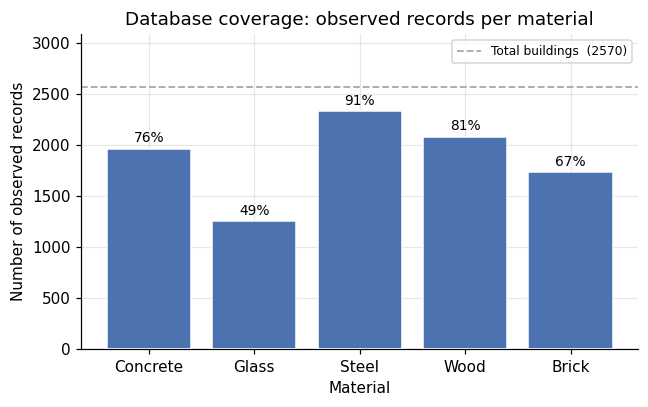

In [70]:
# ==========================================================
# Figure 1 — Database coverage
# ==========================================================

y_all_mask = np.vstack([data["y_train_mask"], data["y_val_mask"], data["y_test_mask"]])
n_total    = len(y_all_mask)
n_obs      = y_all_mask.sum(axis=0)
pct        = n_obs / n_total * 100

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, n_obs, color=_C1, edgecolor="white", zorder=3)
ax.axhline(n_total, color=_GRAY, lw=1.2, ls="--",
           label=f"Total buildings  ({n_total})", zorder=2)
for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + n_total * 0.012,
            f"{p:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Material")
ax.set_ylabel("Number of observed records")
ax.set_title("Database coverage: observed records per material")
ax.set_ylim(0, n_total * 1.20)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 2 — Observation model performance by material

AUC-ROC of the Stage 1 observation model on the test set, per material. A higher
AUC indicates the model better distinguishes buildings with a recorded value from
those without. The dashed red line marks the random-classifier baseline (AUC = 0.5).


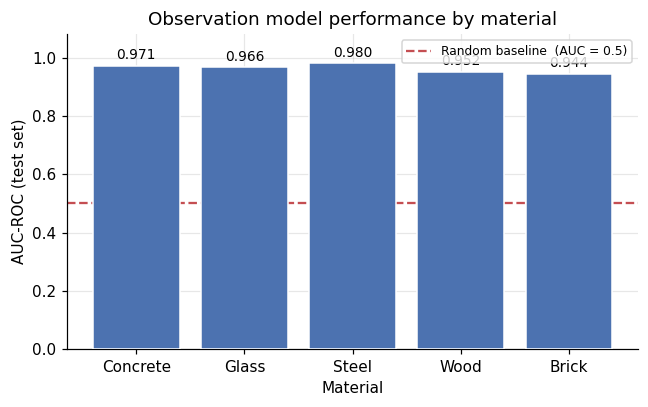

In [71]:
# ==========================================================
# Figure 2 — Observation model performance (AUC)
# ==========================================================

aucs   = [_val(mat, "AUC") for mat in y_cols]
colors = [_C1 if not pd.isna(v) else _GRAY for v in aucs]
vals   = [v if not pd.isna(v) else 0.0 for v in aucs]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
ax.axhline(0.5, color=_REF, lw=1.5, ls="--",
           label="Random baseline  (AUC = 0.5)", zorder=2)
for bar, v in zip(bars, aucs):
    if not pd.isna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.08)
ax.set_xlabel("Material")
ax.set_ylabel("AUC-ROC (test set)")
ax.set_title("Observation model performance by material")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 3 — Conditional reported-intensity model error by material

Mean absolute error (MAE, kg/m²) of the Stage 2 model's median prediction (p50)
against observed reported intensity values on the test set. Only buildings where
the material was recorded are included. Lower MAE indicates more accurate
conditional intensity estimates.


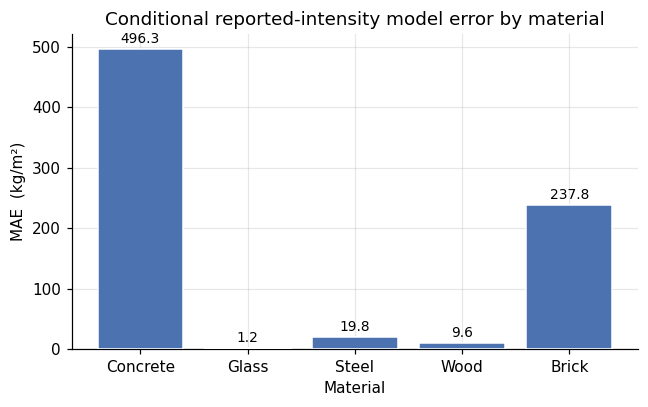

In [72]:
# ==========================================================
# Figure 3 — Conditional intensity model error (MAE)
# ==========================================================

maes   = [_val(mat, "MAE") for mat in y_cols]
colors = [_C1 if not pd.isna(v) else _GRAY for v in maes]
vals   = [v if not pd.isna(v) else 0.0 for v in maes]

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(y_cols, vals, color=colors, edgecolor="white", zorder=3)
for bar, v in zip(bars, maes):
    if not pd.isna(v) and v > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.012,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Material")
ax.set_ylabel("MAE  (kg/m²)")
ax.set_title("Conditional reported-intensity model error by material")
plt.tight_layout()
plt.show()


### Figure 4 — Observed vs predicted reported intensity (test set)

Each panel shows observed reported intensity (x-axis) against the model's
median prediction, p50, (y-axis) for buildings where that material was recorded.
Points near the 1:1 reference line indicate accurate predictions.
Log scale is applied where the 5th–95th percentile range spans more than
one order of magnitude.


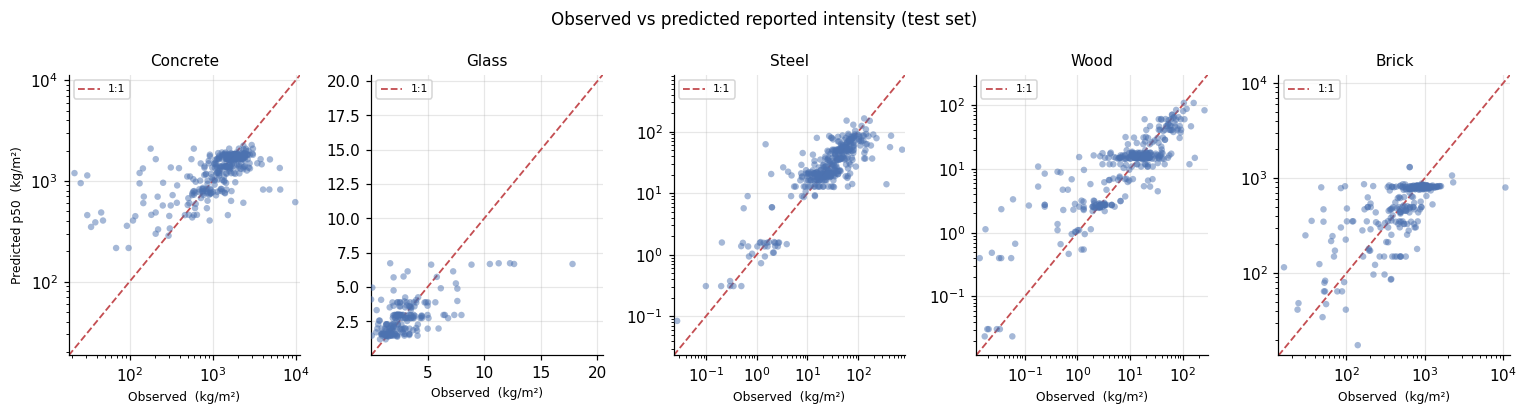

In [73]:
# ==========================================================
# Figure 4 — Observed vs predicted reported intensity
# ==========================================================

fig, axes = plt.subplots(1, len(y_cols), figsize=(14, 3.8))

for ax, m in zip(axes, range(len(y_cols))):
    mat  = y_cols[m]
    obs  = data["y_test_mask"][:, m]
    if obs.sum() < 2:
        ax.text(0.5, 0.5, "insufficient\ndata", transform=ax.transAxes,
                ha="center", va="center", color=_GRAY)
        ax.set_title(mat, fontsize=10)
        continue

    y_true = data["y_test_raw"][obs, m]
    y_pred = intervals_test[mat]["p50"][obs]

    use_log = (len(y_true) > 4 and
               np.percentile(y_true, 95) / (np.percentile(y_true, 5) + 1e-6) > 10)

    ax.scatter(y_true, y_pred, s=18, alpha=0.5, color=_C1, edgecolors="none", zorder=3)

    lo = min(y_true.min(), y_pred.min()) * 0.85
    hi = max(y_true.max(), y_pred.max()) * 1.15
    if use_log:
        lo = max(lo, 1e-2)
    ax.plot([lo, hi], [lo, hi], color=_REF, lw=1.2, ls="--", label="1:1", zorder=2)

    if use_log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_title(mat, fontsize=10)
    ax.set_xlabel("Observed  (kg/m²)", fontsize=8)
    if m == 0:
        ax.set_ylabel("Predicted p50  (kg/m²)", fontsize=8)
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Observed vs predicted reported intensity (test set)", fontsize=11)
plt.tight_layout()
plt.show()


### Figure 5 — Empirical coverage of 90% prediction intervals

Each bar shows the fraction of test-set observations that fall within the model's
predicted 90% interval (p05–p95) for that material. Bars close to the dashed
reference line at 0.90 indicate well-calibrated intervals. Over-coverage (bar > 0.90)
suggests the intervals are too wide; under-coverage suggests they are too narrow.


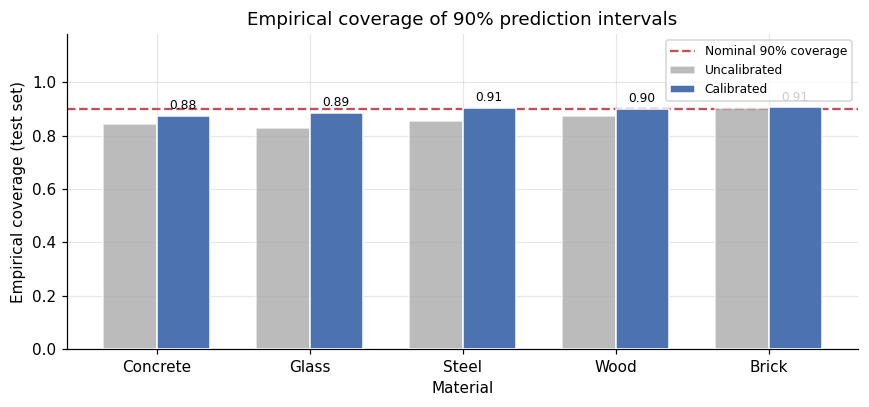

In [74]:
# ==========================================================
# Figure 5 — Empirical interval coverage
# ==========================================================

covs_u = [_val(mat, "CovU") for mat in y_cols]
covs_c = [_val(mat, "CovC") for mat in y_cols]
colors = [(_C1 if abs(v - 0.9) <= 0.1 else _C2) if not pd.isna(v) else _GRAY
          for v in covs_c]
vals_u = [v if not pd.isna(v) else 0.0 for v in covs_u]
vals_c = [v if not pd.isna(v) else 0.0 for v in covs_c]

x = np.arange(len(y_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 3.8))
bars_u = ax.bar(x - width / 2, vals_u, width, color=_GRAY,   edgecolor="white", label="Uncalibrated",  zorder=3, alpha=0.8)
bars_c = ax.bar(x + width / 2, vals_c, width, color=colors,  edgecolor="white", label="Calibrated",    zorder=3)
ax.axhline(0.90, color=_REF, lw=1.5, ls="--",
           label="Nominal 90% coverage", zorder=2)
for bar, v in zip(bars_c, covs_c):
    if not pd.isna(v):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.18)
ax.set_xticks(x)
ax.set_xticklabels(y_cols)
ax.set_xlabel("Material")
ax.set_ylabel("Empirical coverage (test set)")
ax.set_title("Empirical coverage of 90% prediction intervals")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Figure 6 — Example query output for a single building

This panel illustrates how to interpret `FinalQueryModel.query()` output for one
building from the test set. The **left panel** shows the recording probability
for each material — the estimated chance that the database contains a value for this
building type. The **right panel** shows the conditional reported intensity (bar = p50)
with the 90% prediction interval (error bars); orange dots show the expected reported
intensity, which is the recording probability multiplied by the conditional median.


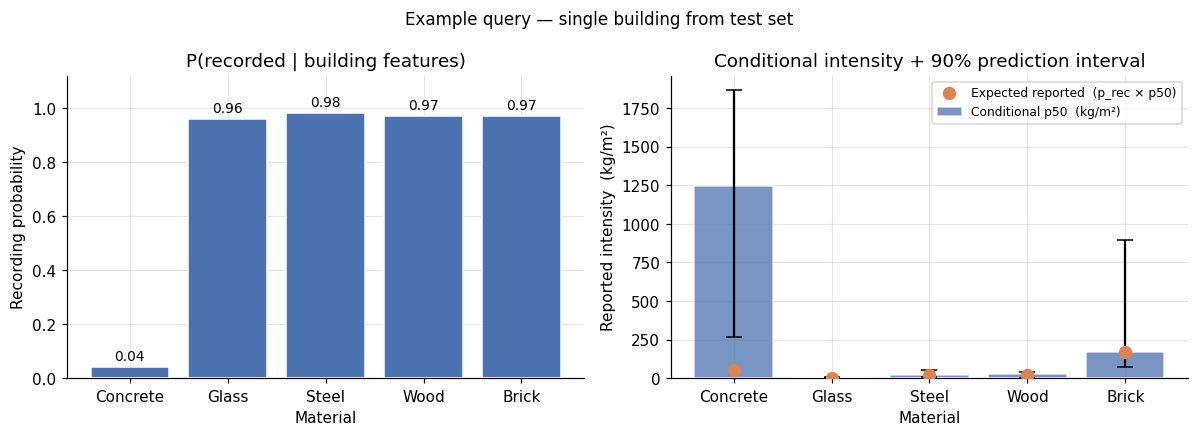


Example building features:
  Construction period: 1999
  Construction period bucket: 1980_2000
  Typology: R-UNK
  Primary Code: S
  Hybrid Structure: 1
  Country: China

Archetype support in training data: 13 rows (medium)


In [75]:
# ==========================================================
# Figure 6 — Example query output
# ==========================================================

# Pick first test row where at least 3 materials are recorded
example_idx = next(
    (i for i in range(len(data["X_test_proc"]))
     if data["y_test_mask"][i].sum() >= 3),
    0,
)
X_ex     = data["X_test_proc"][example_idx : example_idx + 1]
X_ex_raw = data["X_test_raw"].iloc[example_idx : example_idx + 1][X_cols]
result   = final_query_model.query(X_ex, X_raw=X_ex_raw)

p_rec   = [float(result[mat]["p_recorded"][0])       for mat in y_cols]
p50     = [float(result[mat]["p50"][0])               for mat in y_cols]
p05     = [float(result[mat]["p05"][0])               for mat in y_cols]
p95     = [float(result[mat]["p95"][0])               for mat in y_cols]
exp_rep = [float(result[mat]["expected_reported"][0]) for mat in y_cols]
x       = np.arange(len(y_cols))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# -- Left: recording probability --
ax1.bar(y_cols, p_rec, color=_C1, edgecolor="white", zorder=3)
for i, v in enumerate(p_rec):
    ax1.text(i, v + 0.025, f"{v:.2f}", ha="center", fontsize=9)
ax1.set_ylim(0, 1.12)
ax1.set_xlabel("Material")
ax1.set_ylabel("Recording probability")
ax1.set_title("P(recorded | building features)")

# -- Right: conditional intensity + PI --
err_lo = [max(p50[i] - p05[i], 0.0) for i in range(len(y_cols))]
err_hi = [max(p95[i] - p50[i], 0.0) for i in range(len(y_cols))]
ax2.bar(x, p50, color=_C1, alpha=0.75, edgecolor="white",
        label="Conditional p50  (kg/m²)", zorder=3)
ax2.errorbar(x, p50, yerr=[err_lo, err_hi],
             fmt="none", color="black", capsize=5, lw=1.5, zorder=4)
ax2.scatter(x, exp_rep, color=_C2, zorder=5, s=60,
            label="Expected reported  (p_rec × p50)")
ax2.set_xticks(x)
ax2.set_xticklabels(y_cols)
ax2.set_xlabel("Material")
ax2.set_ylabel("Reported intensity  (kg/m²)")
ax2.set_title("Conditional intensity + 90% prediction interval")
ax2.legend(fontsize=8)

fig.suptitle("Example query — single building from test set", fontsize=11)
plt.tight_layout()
plt.show()

# Print building context + archetype support
bldg = data["X_test_raw"].iloc[example_idx]
print("\nExample building features:")
for col in X_cols:
    print(f"  {col}: {bldg[col]}")

archetype_n = int(result[y_cols[0]]["archetype_n_train"][0])
archetype_lvl = result[y_cols[0]]["archetype_support_level"][0]
print(f"\nArchetype support in training data: {archetype_n} rows ({archetype_lvl})")


In [76]:
# ==========================================================
# Save All Application-Required Files
# ==========================================================
#
# Files saved

import json as _json

# 1. Trained model
joblib.dump(final_query_model, "model.joblib")
print("Saved: model.joblib")

# 2. Preprocessor  (required to transform raw X before calling query())
joblib.dump(data["preprocessor"], "preprocessor.joblib")
print("Saved: preprocessor.joblib")

# 3. Evaluation results
summary_df.to_csv("evaluation_summary.csv", index=False)
print("Saved: evaluation_summary.csv")

# 4. Model metadata  (column names, constants, data-split sizes)
_model_info = {
    "X_cols":              X_cols,
    "y_cols":              y_cols,
    "SEED":                SEED,
    "LOW_OBS_THRESHOLD":   LOW_OBS_THRESHOLD,
    "n_observed_train":    final_query_model.n_observed_train_,
    "data_split": {
        "n_train": int(len(data["X_train_proc"])),
        "n_val":   int(len(data["X_val_proc"])),
        "n_test":  int(len(data["X_test_proc"])),
    },
}
with open("model_info.json", "w") as _f:
    _json.dump(_model_info, _f, indent=2)
print("Saved: model_info.json")

Saved: model.joblib
Saved: preprocessor.joblib
Saved: evaluation_summary.csv
Saved: model_info.json
